## Horn Antenna

This notebook explores the design and discretization of a horn antenna. As part of our coursework, we will focus on generating a high-quality mesh that captures the geometry of the flared aperture, which is critical for accurate signal radiation. We will implement mesh refinement techniques to ensure the model effectively resolves the electromagnetic fields near the transition. The process concludes by exporting the finalized mesh, formatted for use in the Palace solver, where we will ultimately evaluate the antenna’s performance.

In [1]:
import gmsh
import math
import os
import json
from pathlib import Path

from palacetoolkit.geometry import xmin, xmax, ymin, ymax, zmin, zmax, extract_tag
from palacetoolkit.viz import run_with_scrollable_output, view_mesh
from palacetoolkit.mesh import (
    Entity,
    run_meshing_pipeline,
    generate_3d_mesh,
    refine_near_surfaces
)

### Parameters:
 - filename : name of the mesh file to generate (e.g., "horn_antenna.msh")
 - waveguide_length : length of the waveguide section
 - waveguide_width : width of the waveguide section
 - waveguide_height : height of the waveguide section
 - flare_length : length of the flare section
 - flare_width : width of the flare section at the aperture
 - flare_height : height of the flare section at the aperture
 - freq_ghz : frequency of operation in GHz
 - gui : whether to launch the Gmsh GUI for visualization (True/False)
 - mesh_order : The order of interpolation for the finite element basis functions.

In [2]:
filename = "horn_antenna.msh"
waveguide_length = 0.3
waveguide_width = 9.373e-2
waveguide_height = 4.166e-2
flare_length = 0.84
flare_width = 30.0 * 0.0254
flare_height = 23.8 * 0.0254
freq_ghz = 1.8
gui = False
mesh_order = 1 

# Wavelength in free space (lambda_0 = c / f).
c0 = 3e8 
wavelength = c0 / (freq_ghz * 1e9)

lc = wavelength / 4

### Initializing the Modeling Environment

In [3]:
gmsh.initialize()
gmsh.option.setNumber("General.Verbosity", 5)
gmsh.model.add("horn_antenna")
kernel = gmsh.model.occ

### Geometry Construction and Domain Definition
In this step, we build the horn antenna geometry using the OpenCASCADE kernel. We define the waveguide input and the flared aperture as separate surface loops, connect them to form the solid volume, and finally define a surrounding spherical air domain. The geometry is fragmented to ensure consistent meshing across the waveguide and the radiation domain.

In [4]:
# Waveguide internal face
kernel.addPoint(-waveguide_width/2, -waveguide_height/2, 0, lc, 1)
kernel.addPoint(waveguide_width/2, -waveguide_height/2, 0, lc, 2)
kernel.addPoint(waveguide_width/2, waveguide_height/2, 0, lc, 3)
kernel.addPoint(-waveguide_width/2, waveguide_height/2, 0, lc, 4)

kernel.addLine(1, 2, 1)
kernel.addLine(2, 3, 2)
kernel.addLine(3, 4, 3)
kernel.addLine(4, 1, 4)

kernel.addCurveLoop([4, 1, 2, 3], 1)
kernel.addPlaneSurface([1], 1)

# Flare faces. We only generate the four sides. 
kernel.addPoint(-flare_width/2, -flare_height/2, flare_length, lc, 5)
kernel.addPoint(flare_width/2, -flare_height/2, flare_length, lc, 6)
kernel.addPoint(flare_width/2,  flare_height/2, flare_length, lc, 7)
kernel.addPoint(-flare_width/2, flare_height/2, flare_length, lc, 8)

kernel.addLine(5, 6, 5)
kernel.addLine(6, 7, 6)
kernel.addLine(7, 8, 7)
kernel.addLine(8, 5, 8)

# Connect faces
kernel.addLine(1, 5, 9)  
kernel.addLine(2, 6, 10) 
kernel.addLine(3, 7, 11) 
kernel.addLine(4, 8, 12)

kernel.addCurveLoop([1, 10, -5, -9], 3)
kernel.addPlaneSurface([3], 3)
kernel.addCurveLoop([2, 11, -6, -10], 4)
kernel.addPlaneSurface([4], 4)
kernel.addCurveLoop([3, 12, -7, -11], 5)
kernel.addPlaneSurface([5], 5)
kernel.addCurveLoop([4, 9, -8, -12], 6)
kernel.addPlaneSurface([6], 6)

# Surfaces
flare = [3, 4, 5, 6]
waveguide = kernel.extrude([(2, 1)], 0, 0, -waveguide_length)

# Only the 2d surfaces
waveguide = [(d, t) for (d, t) in waveguide if d == 2]

# Air domain
outer_radius = max(1.8 * wavelength, 1.1 * flare_length)
outer_boundary = kernel.addSphere(0, 0, flare_length/2, outer_radius)

# Now, we want the external face of the waveguide to be the waveport, and also we do not want 
# the 'interior' face. 

# Finds the face between the waveguide and the flare.
def is_internal_face(dimtag):
    return math.isclose(zmin(dimtag), 0, abs_tol=1e-6) and math.isclose(zmax(dimtag), 0, abs_tol=1e-6)

# Findes the external face.
def is_external_face(dimtag):
    return math.isclose(zmin(dimtag), -waveguide_length, abs_tol=1e-6) and math.isclose(zmax(dimtag), -waveguide_length, abs_tol=1e-6)

# Filter and waveport
waveport = [t for (d, t) in waveguide if is_external_face((d, t))]
waveguide = [t for (d, t) in waveguide if not (is_internal_face((d, t)) or is_external_face((d, t)))] 

print("waveguide:", waveguide)
print("flare:", flare)  
print("waveport:", waveport)

waveguide: [7, 8, 9, 10]
flare: [3, 4, 5, 6]
waveport: [11]


In [5]:
# Entity definition
entities = [
    Entity('outer_boundary', 3, 2, [outer_boundary]),
    Entity('waveguide', 2, 1, waveguide),
    Entity('flare', 2, 1, flare),
    Entity('waveport', 2, 1, waveport)
]

# Boolean operations to guarantee a nice mesh, algo it returns the
# physical group map.
pg_map = run_meshing_pipeline(entities)

print(entities)

# Refine near the port
refine_near_surfaces(entities[-1].dimtags, 
                     wavelength, 
                     ppw_near=5, 
                     ppw_far=5, 
                     set_as_background=True)

# Mesh sizes
mesh_sizes = {}

def _generate_horn_mesh():
    generate_3d_mesh(entities, mesh_sizes, filename, optimize=True)
    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.write(filename)

run_with_scrollable_output(_generate_horn_mesh, title="Horn antenna mesh generation", max_lines=10)
gmsh.finalize()

  Physical group 'outer_boundary' (dim=3): pg=1, tags=[2]                                                                                  
  Physical group 'waveguide' (dim=2): pg=2, tags=[9, 10, 7, 8]
  Physical group 'flare' (dim=2): pg=3, tags=[3, 4, 5, 6]
  Physical group 'waveport' (dim=2): pg=4, tags=[11]
  Physical group 'outer_boundary__None' (dim=2): pg=5, tags=[12]
[Entity('outer_boundary', dim=3, order=2, tags=[2]), Entity('waveguide', dim=2, order=1, tags=[9, 10, 7, 8]), Entity('flare', dim=2, order=1, tags=[3, 4, 5, 6]), Entity('waveport', dim=2, order=1, tags=[11])]
  ppw_near=5  ppw_far=5
  SizeMax=0.0333  transition=0.0417
  global: 4 curves, SizeMin=0.0333


Mesh saved to horn_antenna.msh
  Nodes: 14598
  Elements: 29879


### Mesh visualization.

Loading mesh file: horn_antenna.msh
Groups to render transparent: outer_boundary__None

Mesh loaded successfully with 1 cell blocks
Found 29040 triangles total
Physical group tags in mesh: {2: 'waveguide', 3: 'flare', 4: 'waveport', 5: 'outer_boundary__None'}


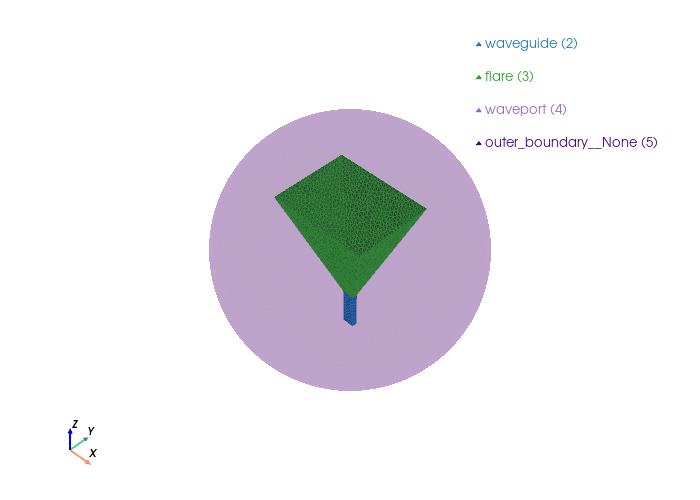

In [23]:
import pyvista as pv

# trame for interactive visualization in the notebook.
pv.set_jupyter_backend("trame")

# Visualize the mesh in the notebook.
view_mesh(filename, transparent_groups="outer_boundary__None", azimuth = 90, elevation = 100)

### Output configuration for Palace JSON input file

In [7]:
freq_min = 1.8
freq_max = 1.8
freq_step = 0.1

# absorbing boundary condition order (1 for first-order ABC, 2 for second-order ABC, etc.)
abc_order = 2
solver_order = 2

output_file = "horn_antenna.json"

### Generating the Palace Configuration File
Finally, we assemble the simulation parameters into a JSON configuration file. This dictionary defines the electromagnetic problem type, assigns material properties to our physical volumes, sets boundary conditions (such as the WavePort excitation and absorbing boundaries), and configures the solver's convergence criteria. This file serves as the definitive input for Palace to execute the full-wave analysis of the horn antenna.

In [8]:
output_stem = Path(filename).stem

config = {
    "Problem": {"Type": "Driven", "Verbose": 2, "Output": f"/work/postpro/{output_stem}"},
    "Model": {"Mesh": f"/work/{filename}", "L0": 1.0},
    "Domains": {
        "Materials": [{
            "Attributes": [pg_map["outer_boundary"]],
            "Permeability": 1.0, "Permittivity": 1.0, "LossTan": 0.0
        }]
    },
    "Boundaries": {
        "Absorbing": {"Attributes": [pg_map["outer_boundary__None"]], "Order": abc_order},
        "PEC": {"Attributes": [pg_map["waveguide"], pg_map["flare"]]},
        "Postprocessing": {
            "FarField": {
                "Attributes": [pg_map["outer_boundary__None"]],
                "NSample": 64000 
            }
        },
        "WavePort": [{
            "Index": 1, "Attributes": [pg_map["waveport"]],
            "Mode": 1, "Offset": 0.0, "Excitation": True
        }]
    },
    "Solver": {
        "Order": solver_order, "Device": "CPU",
        "Driven": {"MinFreq": freq_min, "MaxFreq": freq_max, "FreqStep": freq_step, "SaveStep": 1, "AdaptiveTol": 0.0001},
        "Linear": {"Type": "Default", "KSPType": "GMRES", "Tol": 1e-7, "MaxIts": 3000, "MaxSize": 1000, "ComplexCoarseSolve": True}
    }
}

script_dir = os.getcwd()
config_path = os.path.join(script_dir, output_file)
with open(config_path, "w") as f: json.dump(config, f, indent=2)